# 자연언어처리 01주차 실습: Google Colab 환경 구축

**제출용 완성 노트북**입니다. 안내된 순서대로 코드를 실행하고, `TODO`로 표시된 부분을 직접 완성했습니다.

## 오늘의 목표
1. Google Colab에서 파이썬 실행 환경을 확인한다.
2. 자연어처리 실습에 필요한 라이브러리를 설치한다.
3. 한국어가 그래프에서 정상적으로 출력되도록 설정한다.
4. Kiwi와 KoNLPy를 이용해 한국어 문장을 형태소 단위로 분석한다.
5. GitHub를 활용한 실습 코드 관리 흐름을 이해한다.

> **제출 전 유의사항**: 실행 결과가 보이도록 저장하고, 본인이 작성한 TODO 코드와 짧은 해석을 남기세요.


## 실습 규칙

- 코드는 위에서 아래 순서로 실행합니다.
- 패키지 설치 후 오류가 계속되면 `런타임 → 런타임 다시 시작` 후 설치 셀부터 다시 실행합니다.
- TODO를 해결할 때에는 결과만 복사하지 말고, 사용한 함수가 무엇을 하는지 한 줄로 설명합니다.
- 공개 GitHub 저장소에는 개인정보, 비밀번호, 인증 토큰을 올리지 않습니다.


## 1. 실행 환경 확인

Colab은 웹 브라우저에서 파이썬 코드를 실행할 수 있는 환경입니다. 아래 셀을 실행한 뒤 현재 Python 버전과 운영체제 정보를 확인하세요.


In [1]:
import sys
import platform

print(f"Python version : {sys.version.split()[0]}")
print(f"Platform       : {platform.platform()}")


Python version : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35


### 체크포인트 1

아래 문장을 Markdown 셀로 추가하여 답하세요.

- 내가 사용하는 Python 버전은 무엇인가?
- 이번 주차에 GPU가 반드시 필요하지 않은 이유는 무엇인가?

**답변**

- 위 실행 결과에서 확인한 Python 버전은 **3.13.15**이다.
- 이번 주차는 환경 확인, 기본 그래프 작성, 정규표현식 기반 정제와 형태소 분석처럼 계산량이 크지 않은 작업을 수행하므로 GPU가 반드시 필요하지 않다.


## 2. 필수 라이브러리 설치

이번 학기에는 다음과 같은 도구를 사용합니다.

- `pandas`, `numpy`: 데이터 처리
- `matplotlib`, `seaborn`: 시각화
- `scikit-learn`: TF-IDF 등 전통 머신러닝
- `kiwipiepy`, `konlpy`: 한국어 형태소 분석
- `transformers`, `datasets`: 후반부 Transformer·LLM 실습

아래 설치 셀을 실행하세요.


In [2]:
# Google Colab에서는 실습에 필요한 패키지를 설치합니다.
# 로컬 검증 환경에서는 이미 설치된 패키지를 사용하여 불필요한 재설치를 피합니다.
import sys

if "google.colab" in sys.modules:
    !pip -q install -U kiwipiepy konlpy sentencepiece transformers datasets
    !pip -q install -U matplotlib seaborn scikit-learn
    !pip -q install --no-cache-dir "numpy>=2.0,<2.3" "pandas==2.2.3"
    print("필수 라이브러리 설치 완료")
else:
    print("로컬 검증 환경: 현재 환경에 설치된 패키지를 사용합니다.")

필수 라이브러리 설치 완료


In [3]:
# 설치 확인: 핵심 패키지의 버전을 출력합니다.
import pandas as pd
import numpy as np
import sklearn
import kiwipiepy

print("pandas:", pd.__version__)
# TODO 1 완료: np.__version__은 현재 설치된 NumPy 버전 문자열을 반환합니다.
print("numpy:", np.__version__)

# TODO 2 완료: kiwipiepy.__version__은 현재 설치된 Kiwi 패키지 버전을 반환합니다.
print("kiwipiepy:", kiwipiepy.__version__)

print("scikit-learn:", sklearn.__version__)


pandas: 2.2.3
numpy: 2.1.3
kiwipiepy: 0.23.2
scikit-learn: 1.9.0


### 체크포인트 2

- `pandas`는 텍스트 데이터를 표 형태로 다룰 때 어떤 역할을 할까요?
- `kiwipiepy`는 이후 전처리 단계에서 왜 필요할까요?

각 질문에 1~2문장으로 답하세요.

**답변**

- `pandas`는 문장, 레이블, 작성일 등의 텍스트 관련 값을 행과 열로 구성된 `DataFrame`에 저장하고, 결측치 처리·필터링·집계 같은 작업을 수행하는 데 사용된다.
- `kiwipiepy`는 한국어 문장을 형태소 단위로 나누고 품사 태그를 제공하므로, 명사 추출·불용어 처리·토큰화 등 이후 전처리에 필요하다.


## 3. 한글 폰트 설정 및 시각화

텍스트 데이터의 빈도나 길이를 그래프로 표현할 때 한글이 깨지지 않아야 합니다. 아래 셀을 실행해 나눔 폰트를 설치하고 Matplotlib에 적용하세요.


In [4]:
# Colab에서 한글 폰트를 설치합니다.

import sys

if "google.colab" in sys.modules:
    !apt-get -qq update
    !apt-get -qq install -y fonts-nanum
    !fc-cache -fv > /dev/null
else:
    print("로컬 검증 환경: 시스템 한글 폰트를 사용합니다.")

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

print("한글 폰트 설정 완료")


한글 폰트 설정 완료


In [5]:
# matplotlib의 폰트 매니저에 수동으로 추가

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

from pathlib import Path

colab_font = Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
mac_font = Path('/System/Library/Fonts/Supplemental/AppleGothic.ttf')
font_path = str(colab_font if colab_font.exists() else mac_font)
if not Path(font_path).exists():
    raise FileNotFoundError("사용 가능한 한글 폰트를 찾지 못했습니다.")
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)  # 'NanumGothic' 이 출력되어야 함

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

NanumGothic


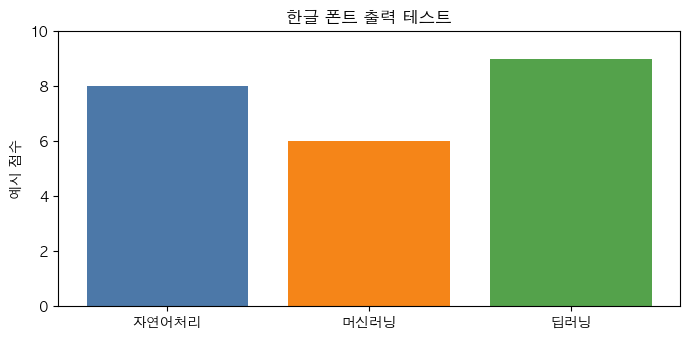

In [6]:
# TODO 3 완료: 아래 범주와 수치를 사용하여 막대그래프를 작성합니다.
categories = ["자연어처리", "머신러닝", "딥러닝"]
values = [8, 6, 9]

plt.figure(figsize=(7, 3.5))
# plt.bar(x, height)는 범주별 높이를 가진 세로 막대그래프를 만듭니다.
plt.bar(categories, values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("한글 폰트 출력 테스트")
plt.ylabel("예시 점수")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


### 체크포인트 3

그래프의 제목과 x축 범주가 한글로 보이는지 확인하세요. 만약 글자가 깨진다면 가능한 원인과 해결 방법을 한 줄로 작성하세요.

**확인 결과:** 그래프 제목, y축 이름, x축의 `자연어처리`, `머신러닝`, `딥러닝`이 모두 한글로 정상 출력되었다. 한글이 깨질 경우 나눔 폰트가 설치 또는 등록되지 않았거나 폰트 설정 전에 그래프를 그린 것이 원인일 수 있으므로, 폰트를 다시 설치·등록한 뒤 폰트 설정 셀부터 재실행한다.


## 4. Kiwi로 한국어 형태소 분석하기

한국어는 조사와 어미가 결합하므로 공백만으로 단어를 나누면 의미 있는 분석 단위를 얻기 어렵습니다. Kiwi는 문장을 **형태소**와 **품사 태그**로 분리해 줍니다.


In [7]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("입력 문장:", text)
print("\n[형태소 분석 결과]")
for token in kiwi.tokenize(text):
    print(f"{token.form:10s} | {token.tag}")


입력 문장: 자연어처리 수업에서 한국어 텍스트를 분석합니다.

[형태소 분석 결과]
자연어 처리     | NNP
수업         | NNG
에서         | JKB
한국어        | NNP
텍스트        | NNG
를          | JKO
분석         | NNG
하          | XSV
ᆸ니다        | EF
.          | SF


In [8]:
# TODO 4 완료: 위 문장에서 명사 태그(N으로 시작하는 품사)만 추출합니다.
# 힌트: token.tag.startswith("N")

# 리스트 컴프리헨션은 조건을 만족하는 토큰의 형태(form)만 새 리스트로 만듭니다.
nouns = [token.form for token in kiwi.tokenize(text) if token.tag.startswith("N")]
print("명사:", nouns)


명사: ['자연어 처리', '수업', '한국어', '텍스트', '분석']


### 체크포인트 4

출력된 형태소 중 하나를 골라 **형태소 / 품사 태그 / 해당 품사의 의미**를 작성하세요.

예: `수업 / NNG / 일반 명사`

**답변:** `분석 / NNG / 일반 명사`


## 5. KoNLPy의 Okt 형태소 분석기 사용하기

KoNLPy는 여러 한국어 형태소 분석기를 파이썬에서 사용할 수 있게 해주는 라이브러리입니다. 아래에서 Okt의 형태소 분석 결과를 Kiwi의 결과와 비교합니다.


In [9]:
from konlpy.tag import Okt

okt = Okt()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("형태소:", okt.morphs(text))
print("명사  :", okt.nouns(text))
print("품사  :", okt.pos(text))


형태소: ['자연어', '처리', '수업', '에서', '한국어', '텍스트', '를', '분석', '합니다', '.']
명사  : ['자연어', '처리', '수업', '한국어', '텍스트', '분석']
품사  : [('자연어', 'Noun'), ('처리', 'Noun'), ('수업', 'Noun'), ('에서', 'Josa'), ('한국어', 'Noun'), ('텍스트', 'Noun'), ('를', 'Josa'), ('분석', 'Noun'), ('합니다', 'Verb'), ('.', 'Punctuation')]


In [10]:
# TODO 5 완료: 직접 작성한 문장을 두 분석기로 형태소 분석합니다.
my_sentence = "나는 오늘도 챗봇과 자연스럽게 대화했다."

print("문장:", my_sentence)
print("Kiwi:", [(t.form, t.tag) for t in kiwi.tokenize(my_sentence)])
# okt.pos()는 문장을 형태소로 나누고 각 형태소의 품사를 함께 반환합니다.
print("Okt :", okt.pos(my_sentence))


문장: 나는 오늘도 챗봇과 자연스럽게 대화했다.
Kiwi: [('나', 'NP'), ('는', 'JX'), ('오늘', 'NNG'), ('도', 'JX'), ('챗봇', 'NNG'), ('과', 'JC'), ('자연', 'NNG'), ('스럽', 'XSA-I'), ('게', 'EC'), ('대화', 'NNG'), ('하', 'XSV'), ('었', 'EP'), ('다', 'EF'), ('.', 'SF')]
Okt : [('나', 'Noun'), ('는', 'Josa'), ('오늘', 'Noun'), ('도', 'Josa'), ('챗봇', 'Noun'), ('과', 'Josa'), ('자연', 'Noun'), ('스럽게', 'Josa'), ('대화', 'Noun'), ('했다', 'Verb'), ('.', 'Punctuation')]


### 비교 질문

Kiwi와 Okt의 결과에서 토큰 분리 또는 품사 태그가 다른 사례를 한 가지 찾아 적으세요. 완전히 같아도 괜찮지만, 그 경우에는 사용한 문장과 결과를 기록하세요.

**비교 결과:** 문장 `나는 오늘도 챗봇과 자연스럽게 대화했다.`에서 Kiwi는 `대화했다`를 `대화/NNG + 하/XSV + 었/EP + 다/EF`로 세밀하게 분석했다. 반면 Okt는 `대화/Noun + 했다/Verb`로 분석했다. 즉, Kiwi가 동사 파생 접미사·선어말 어미·종결 어미를 더 세분하여 분리했다. 또한 Kiwi는 `나`를 대명사(`NP`)로, Okt는 명사(`Noun`)로 분류했다.


## 6. 간단한 텍스트 정제 맛보기

본격적인 텍스트 전처리는 이후 주차에서 다룹니다. 여기서는 특수문자 제거와 공백 정리만 간단히 체험합니다.


In [11]:
import re

sample = "NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)"

# TODO 6 완료: 한글, 영문, 숫자, 공백을 제외한 문자를 공백으로 바꿉니다.
# 힌트: re.sub(패턴, 바꿀문자열, 대상문자열)
# re.sub()는 정규표현식과 일치하는 문자를 지정한 문자열로 치환합니다.
cleaned = re.sub(r"[^가-힣A-Za-z0-9\s]", " ", sample)

# TODO 7 완료: 연속된 공백을 하나로 정리하고 양쪽 공백을 제거합니다.
# \s+는 하나 이상의 공백 문자를 뜻하고, strip()은 문자열 양끝의 공백을 제거합니다.
cleaned = re.sub(r"\s+", " ", cleaned).strip()

print("원문      :", sample)
print("정제 결과 :", cleaned)
print("토큰      :", cleaned.lower().split())


원문      : NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)
정제 결과 : NLP 실습은 재미있습니다 2026년에도 꾸준히 학습해 봅시다
토큰      : ['nlp', '실습은', '재미있습니다', '2026년에도', '꾸준히', '학습해', '봅시다']


### 체크포인트 5

특수문자를 모두 지우는 것이 언제나 좋은 전처리 방법은 아닙니다. 이모지, 해시태그, 느낌표 중 하나를 골라 **삭제하면 잃을 수 있는 정보**를 한 문장으로 설명하세요.

**답변:** 느낌표를 삭제하면 작성자가 표현한 강조, 놀람, 흥분 같은 감정의 강도 정보를 잃을 수 있다.


## 7. GitHub 코드 관리 준비

수업에서 작성한 노트북과 프로젝트 코드는 GitHub 저장소에 체계적으로 기록합니다. 아래는 기본 흐름이며, 실제 저장소 주소와 개인정보는 본인이 설정한 뒤 사용하세요.


In [12]:
# Git 사용자 정보 설정 예시
# 개인정보 보호를 위해 이름과 이메일은 예시 상태로 두며, 실제 저장소 사용 시 본인 정보로 수정합니다.
# !git config --global user.name "본인 이름"
# !git config --global user.email "본인 이메일"

# 민감한 전역 설정 전체를 노트북 출력에 노출하지 않고 Git 설치 여부만 확인합니다.
!git --version


git version 2.34.1


In [13]:
# 저장소 생성 후 기본 작업 흐름 예시
# !git init
# !git add .
# !git commit -m "chore: initialize NLP practice environment"
# !git branch -M main
# !git remote add origin https://github.com/loremipsum0116/NLP_Practice.git
# !git push -u origin main


## 제출 과제: 나의 환경 점검 기록

아래를 모두 완료한 뒤 노트북을 저장하고, 수업에서 안내한 방식으로 제출합니다.

- [x] TODO 1~7을 모두 완성하고 실행했다.
- [x] 한글 막대그래프가 정상 출력되도록 했다.
- [x] 직접 만든 한국어 문장을 Kiwi와 Okt로 분석했다.
- [x] Kiwi와 Okt 결과 차이 또는 관찰 내용을 기록했다.
- [x] 텍스트 정제 결과와 특수문자 처리에 대한 의견을 작성했다.
- [x] GitHub 코드 관리 시 민감정보를 공개하지 않는 이유를 작성했다.

**GitHub 보안 기록:** 개인정보가 공개되면 사생활 침해나 피싱에 악용될 수 있고, 비밀번호나 인증 토큰이 노출되면 제3자가 계정과 저장소에 접근하여 데이터를 변경하거나 삭제할 수 있다. 따라서 민감정보는 공개 저장소에 커밋하지 않고 환경 변수나 GitHub Secrets처럼 별도의 안전한 저장 수단으로 관리해야 한다.

> **제출물**: 실행 결과가 포함된 `.ipynb` 파일 또는 강의에서 지정한 GitHub 저장소 링크


## 다음 주 예고

### 2주차: 자연어와 텍스트 데이터 이해

다음 실습에서는 자연어와 텍스트 데이터의 특성을 이해하고, 정형·반정형·비정형 데이터의 차이, UTF-8 인코딩과 한글 정규화(NFC/NFD), 데이터 품질·윤리, 기초 텍스트 탐색 분석(EDA)을 다룹니다.
이후 주차에서 토큰화·불용어 제거·어간 추출 등 한국어 텍스트 전처리를 본격적으로 학습합니다.

### 미리 준비할 것

-  GitHub 계정 생성 완료
-  Colab 환경 설정 완료
-  1주차 과제 제출 완료
